IMPACTS OF CHANGING ANTHROPOGENIC *CLIMATE FORCING ON PRIMARY PRODUCTIVITY IN THE EASTERN BOUNDARY UPWELLING SYSTEMS

In [ ]:
# THE STUDY AREA MODIFIED FROM CHAVEZ ET MESSIE (2015)

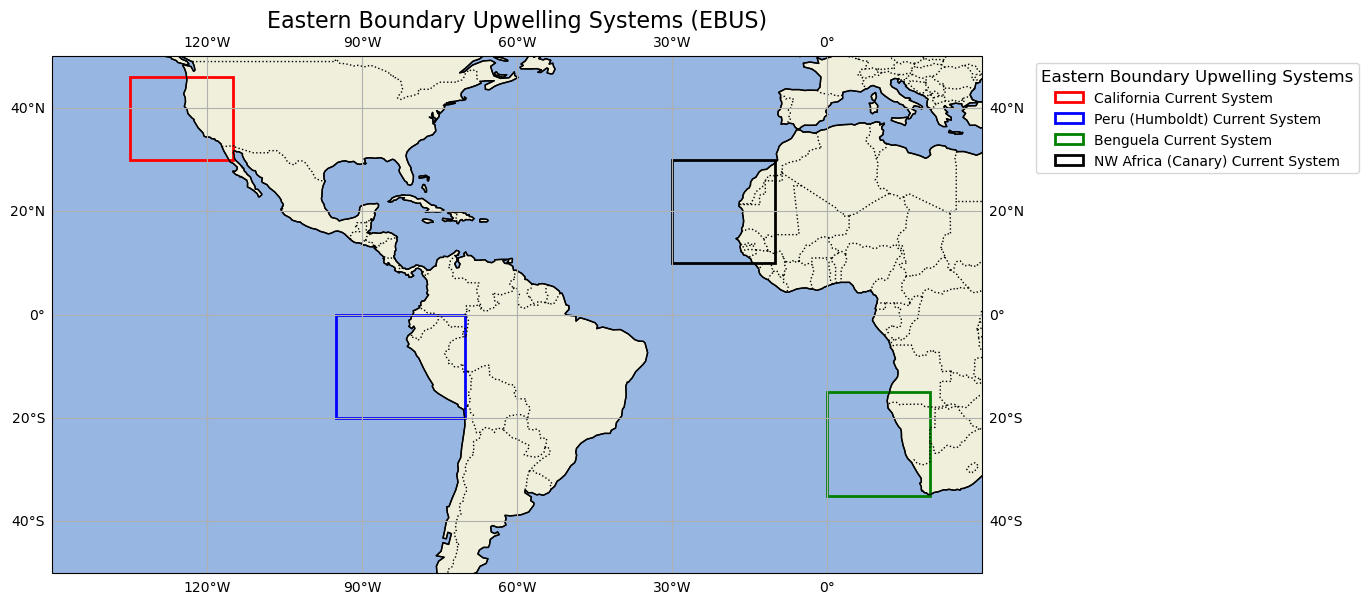

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle

# Updated geographical boundaries for each Eastern Boundary Upwelling System

ebus_regions = {
    "California Current System": {"lon_min": -135, "lon_max": -115, "lat_min": 30, "lat_max": 46},
    "Peru (Humboldt) Current System": {"lon_min": -95, "lon_max": -70, "lat_min": -20, "lat_max": 0},
    "Benguela Current System": {"lon_min": 0, "lon_max": 20, "lat_min": -35, "lat_max": -15},
    "NW Africa (Canary) Current System": {"lon_min": -30, "lon_max": -10, "lat_min": 10, "lat_max": 30}
}


# Set up the map with a projection and zoomed-in extent to focus on the relevant areas
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# Zooming in on EBUS regions more closely
ax.set_extent([-150, 30, -50, 50], crs=ccrs.PlateCarree())

# Add geographical features
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Colors for each upwelling system
colors = ['red', 'blue', 'green', 'black']

# Plot the EBUS regions and store handles for the legend
handles = []
for (name, region), color in zip(ebus_regions.items(), colors):
    # Create a rectangle for each upwelling system
    rect = Rectangle(
        (region["lon_min"], region["lat_min"]),
        region["lon_max"] - region["lon_min"],
        region["lat_max"] - region["lat_min"],
        edgecolor=color, facecolor='none', linewidth=2,
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(rect)
    handles.append((rect, name))

# Adjust the legend to appear on the right side, outside the map
plt.legend(
    [h[0] for h in handles], 
    [h[1] for h in handles], 
    title="Eastern Boundary Upwelling Systems",
    loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=10, title_fontsize=12, frameon=True
)

# Add title and gridlines
plt.title("Eastern Boundary Upwelling Systems (EBUS)", fontsize=16)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
plt.savefig('study area.png', dpi=600)  # Save with higher DPI
plt.show()

In [ ]:
# EXTRACTION OF GLOBAL MODEL DATA FOR THE EBUS 

In [2]:
import xarray as xr
import os

# Define the file paths for the model output data
file_paths = [
    
]

# Define the latitude and longitude bounds for each EBUS region
ebus_regions = {
    "California Current System": {"lon_min": -125, "lon_max": -115, "lat_min": 30, "lat_max": 46},
    "Peru (Humboldt) Current System": {"lon_min": -85, "lon_max": -70, "lat_min": -20, "lat_max": 0},
    "Benguela Current System": {"lon_min": 10, "lon_max": 20, "lat_min": -35, "lat_max": -15},
    "NW Africa (Canary) Current System": {"lon_min": -20, "lon_max": -10, "lat_min": 10, "lat_max": 30},
}

# Output directory for extracted subsets
output_dir = "D:\\THESIS_DATA\\New_Extracted_Model_Outputs"
os.makedirs(output_dir, exist_ok=True)

# Function to subset data for a given region
def subset_ebus_region(dataset, region_name, bounds):
    # Handle longitude bounds (considering 0 to 360 convention)
    if dataset.lon.max() > 180:
        lon_min = (bounds["lon_min"] + 360) if bounds["lon_min"] < 0 else bounds["lon_min"]
        lon_max = (bounds["lon_max"] + 360) if bounds["lon_max"] < 0 else bounds["lon_max"]
    else:
        lon_min = bounds["lon_min"]
        lon_max = bounds["lon_max"]
    
    return dataset.sel(
        lat=slice(bounds["lat_min"], bounds["lat_max"]),
        lon=slice(lon_min, lon_max)
    )

# Loop through each file and extract data for each region
for file_path in file_paths:
    model_name = os.path.basename(file_path).replace(".nc", "")
    try:
        ds = xr.open_dataset(file_path)
    except Exception as e:
        print(f"Error opening file {file_path}: {e}")
        continue

    for region_name, bounds in ebus_regions.items():
        subset = subset_ebus_region(ds, region_name, bounds)
        output_path = os.path.join(output_dir, f"{model_name}_{region_name}_subset.nc")
        
        # Save intermediate result
        subset.to_netcdf(output_path)
        #print(f"Saved {region_name} subset for {model_name} to {output_path}")

print("Extraction completed!")


Extraction completed!


In [ ]:
# PLOTTING TIME SERIES FOR LAST 30 YEARS 

In [ ]:
# TAUU 

C:\Users\DELL\AppData\Local\Temp\ipykernel_11924\3595140416.py:42: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds['time'] = ds.indexes['time'].to_datetimeindex()
C:\Users\DELL\AppData\Local\Temp\ipykernel_11924\3595140416.py:42: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds['time'] = ds.indexes['time'].to_datetimeindex()
C:\Users\DELL\AppData\Local\Temp\ipykernel_11924\3595140416.py:42: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may l

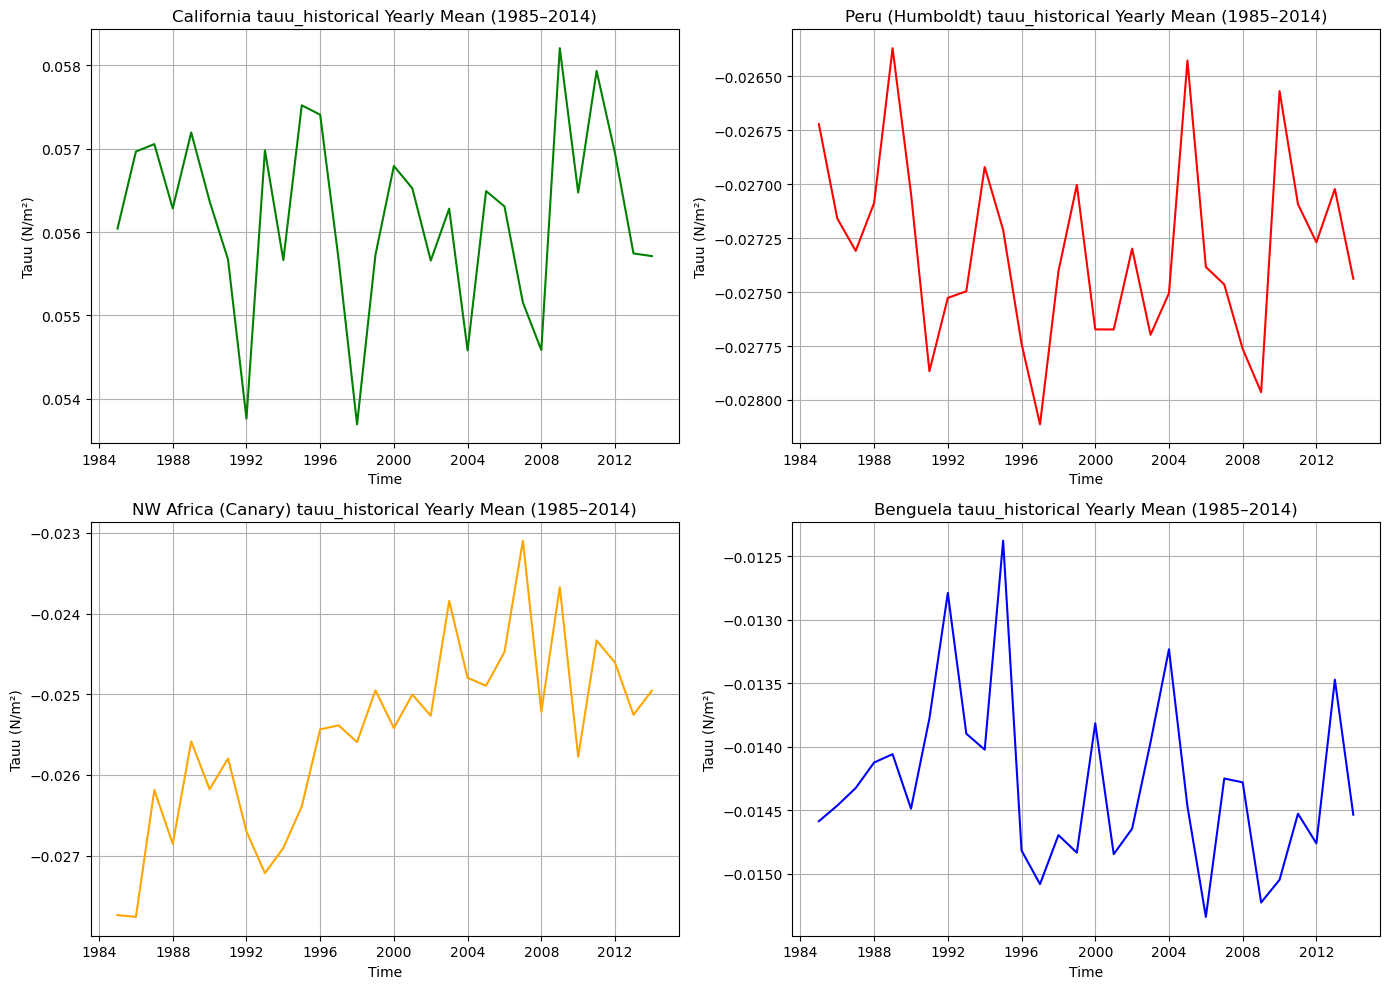

In [44]:
import xarray as xr
import matplotlib.pyplot as plt

# Define file paths for the four EBUS regions (just for tauu_historical)
files = {
    
}

# Variable of interest: tauu_historical
variable = 'tauu_historical'

# Define the time range for the last 30 years (1985-2014)
start_year = 1985
end_year = 2014

# Create a figure for plotting with subplots (2 rows, 2 columns for 4 regions)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Define colors for each region
region_colors = {
    'California': 'green',
    'Peru (Humboldt)': 'red',
    'NW Africa (Canary)': 'orange',
    'Benguela': 'blue',
}

# Loop through the regions and create a subplot for each
for i, (region, file_path) in enumerate(files.items()):
    # Open the dataset for the current region
    ds = xr.open_dataset(file_path)
    
    # Select the time period of interest (1985-2014)
    ds = ds.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
    
    # Convert time to a standard datetime format
    ds['time'] = ds.indexes['time'].to_datetimeindex()
    
    # Extract the tauu_historical variable
    data = ds[variable].mean(dim=['lat', 'lon'])  # Averaging over latitude and longitude
    
    # Resample the data to get yearly means
    yearly_mean = data.resample(time='YS').mean()  # Use 'YS' instead of 'Y' for yearly start
    
    # Plot the yearly mean in the corresponding subplot
    axes[i].plot(yearly_mean.time, yearly_mean, label=f"{region} tauu_historical", color=region_colors[region])

    # Customize the subplot
    axes[i].set_title(f"{region} tauu_historical Yearly Mean (1985–2014)", fontsize=12)
    axes[i].set_xlabel("Time", fontsize=10)
    axes[i].set_ylabel("Tauu (N/m²)", fontsize=10)
    axes[i].grid(True)
    #axes[i].legend()

# Adjust layout for tight spacing
plt.tight_layout()
plt.savefig('tauu time series.png', dpi=600)  # Save with higher DPI
# Show the plot
plt.show()


In [28]:
# TAUV

C:\Users\DELL\AppData\Local\Temp\ipykernel_11924\1141482257.py:43: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds1['time'] = ds1.indexes['time'].to_datetimeindex()
C:\Users\DELL\AppData\Local\Temp\ipykernel_11924\1141482257.py:43: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds1['time'] = ds1.indexes['time'].to_datetimeindex()
C:\Users\DELL\AppData\Local\Temp\ipykernel_11924\1141482257.py:43: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This m

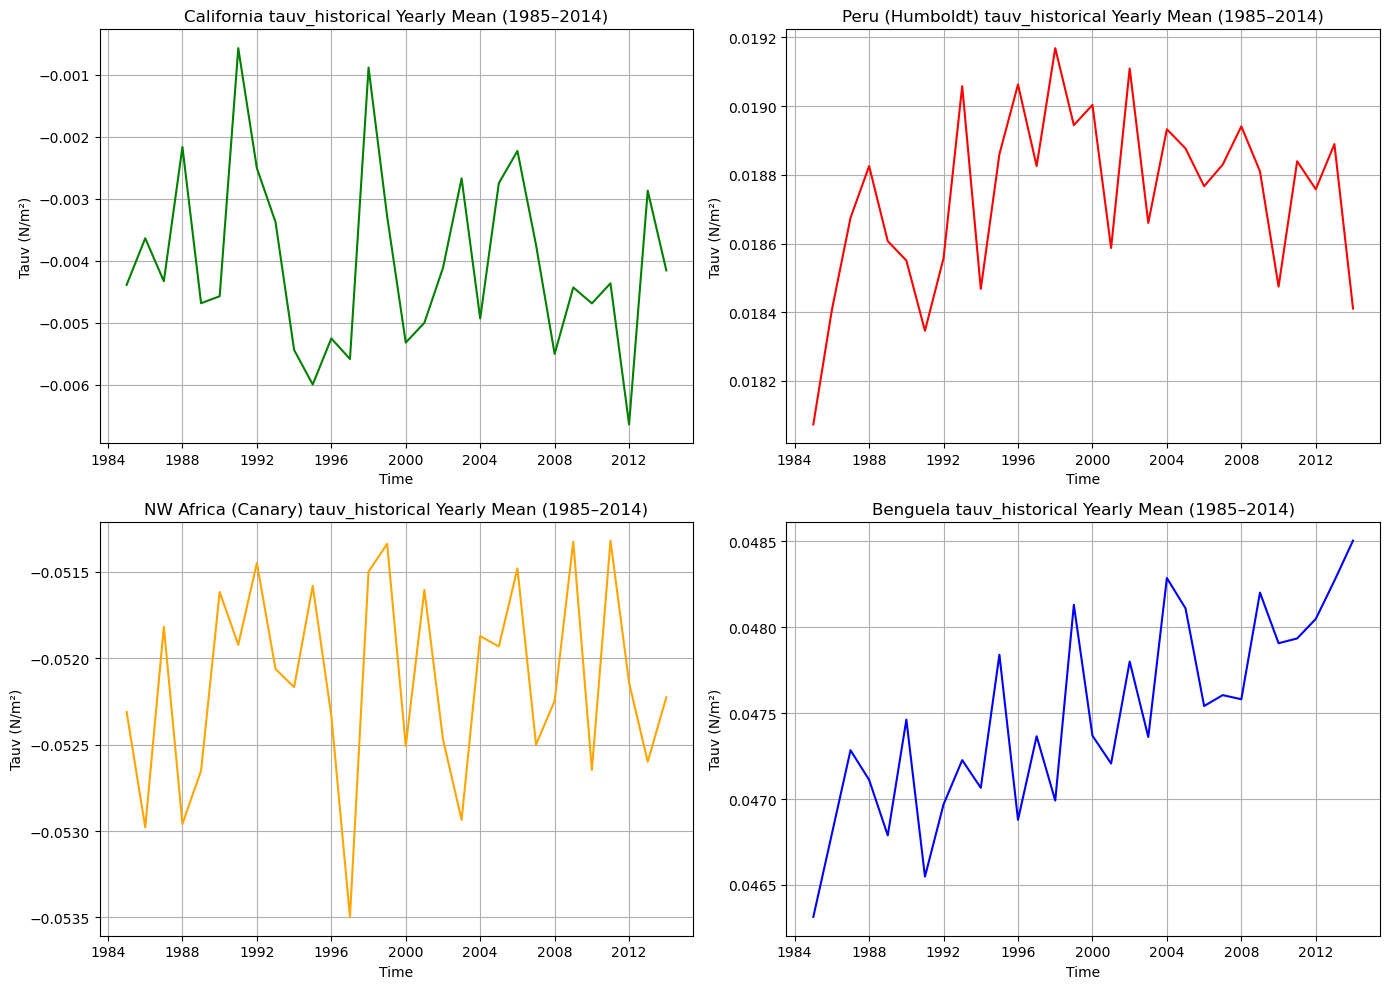

In [45]:
import xarray as xr
import matplotlib.pyplot as plt

# Define the file paths for all scenarios
file_paths1 = {
    'California': r"D:\THESIS_DATA\New_Extracted_Model_Outputs\a_ensmean_tauv_Amon_historical_and_hist-piAer_and_hist-aer_and_hist-ghg_185001-201412_r144x72_California Current System_subset.nc",
    'Peru (Humboldt)': r"D:\THESIS_DATA\New_Extracted_Model_Outputs\a_ensmean_tauv_Amon_historical_and_hist-piAer_and_hist-aer_and_hist-ghg_185001-201412_r144x72_Peru (Humboldt) Current System_subset.nc",
    'NW Africa (Canary)': r"D:\THESIS_DATA\New_Extracted_Model_Outputs\a_ensmean_tauv_Amon_historical_and_hist-piAer_and_hist-aer_and_hist-ghg_185001-201412_r144x72_NW Africa (Canary) Current System_subset.nc",
    'Benguela': r"D:\THESIS_DATA\New_Extracted_Model_Outputs\a_ensmean_tauv_Amon_historical_and_hist-piAer_and_hist-aer_and_hist-ghg_185001-201412_r144x72_Benguela Current System_subset.nc",
}
    

# Variable of interest: tauv_historical
variable = 'tauv_historical'

# Define the time range for the last 30 years (1985-2014)
start_year = 1985
end_year = 2014

# Create a figure for plotting with subplots (2 rows, 2 columns for 4 regions)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Define colors for each region
region_colors = {
    'California': 'green',
    'Peru (Humboldt)': 'red',
    'NW Africa (Canary)': 'orange',
    'Benguela': 'blue',
}

# Loop through the regions and create a subplot for each
for i, (region, file_path1) in enumerate(file_paths1.items()):  # Use file_paths1.items()
    # Open the dataset for the current region
    ds1 = xr.open_dataset(file_path1)
    
    # Select the time period of interest (1985-2014)
    ds1 = ds1.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
    
    # Convert time to a standard datetime format
    ds1['time'] = ds1.indexes['time'].to_datetimeindex()
    
    # Extract the tauv_historical variable
    data = ds1[variable].mean(dim=['lat', 'lon'])  # Averaging over latitude and longitude
    
    # Resample the data to get yearly means
    yearly_mean = data.resample(time='YS').mean()  # Use 'YS' instead of 'Y' for yearly start
    
    # Plot the yearly mean in the corresponding subplot
    axes[i].plot(yearly_mean.time, yearly_mean, label=f"{region} tauv_historical", color=region_colors[region])

    # Customize the subplot
    axes[i].set_title(f"{region} tauv_historical Yearly Mean (1985–2014)", fontsize=12)
    axes[i].set_xlabel("Time", fontsize=10)
    axes[i].set_ylabel("Tauv (N/m²)", fontsize=10)
    axes[i].grid(True)
    #axes[i].legend()

# Adjust layout for tight spacing
plt.tight_layout()
plt.savefig('tauv time series.png', dpi=600)  # Save with higher DPI
# Show the plot
plt.show()


In [ ]:
# TOS

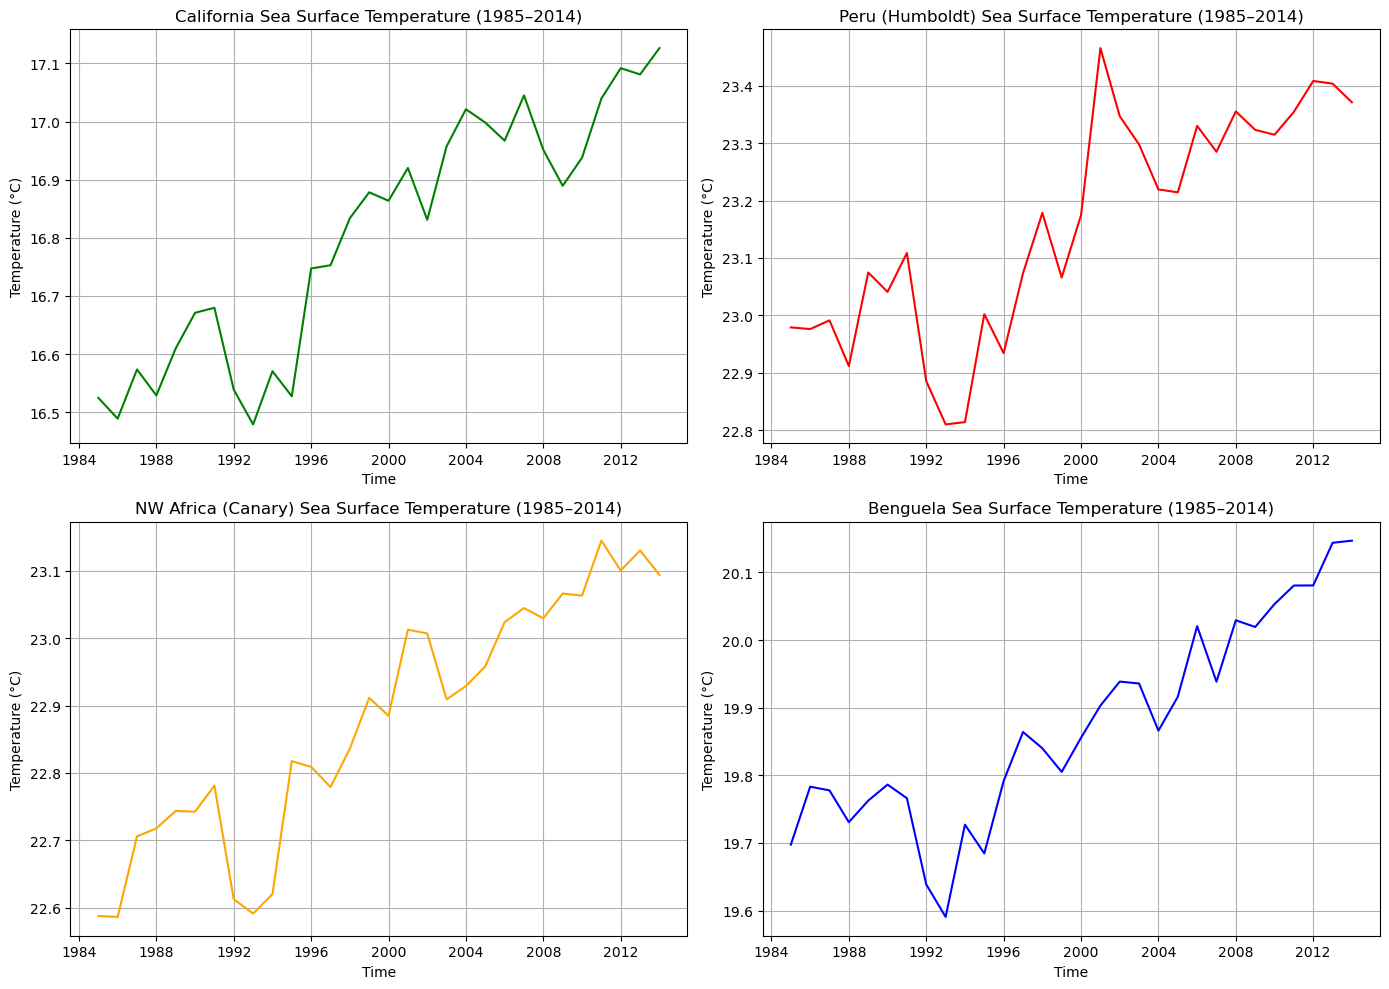

In [46]:
import xarray as xr
import matplotlib.pyplot as plt

# Define the file paths for all scenarios
file_paths2 = {
     
}

# Variable of interest: tos_historical
variable = 'tos_historical'

# Define the time range for the last 30 years (1985-2014)
start_year = 1985
end_year = 2014

# Create a figure for plotting with subplots (2 rows, 2 columns for 4 regions)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Define colors for each region
region_colors = {
    'California': 'green',
    'Peru (Humboldt)': 'red',
    'NW Africa (Canary)': 'orange',
    'Benguela': 'blue',
}

# Loop through the regions and create a subplot for each
for i, (region, file_path2) in enumerate(file_paths2.items()):
    # Open the dataset for the current region
    ds2 = xr.open_dataset(file_path2)
    
    # Sort the time dimension (ensure it is monotonic)
    ds2 = ds2.sortby('time')
    
    # Select the time period of interest (1985-2014)
    ds2 = ds2.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
    
    # Extract the tos_historical variable and compute the mean over lat/lon
    data = ds2[variable].mean(dim=['lat', 'lon'])
    
    # Resample the data to get yearly means
    yearly_mean = data.resample(time='YS').mean()
    
    # Plot the yearly mean in the corresponding subplot
    axes[i].plot(yearly_mean.time, yearly_mean, label=f"{region} tos_historical", color=region_colors[region])

    # Customize the subplot
    axes[i].set_title(f"{region} Sea Surface Temperature (1985–2014)", fontsize=12)
    axes[i].set_xlabel("Time", fontsize=10)
    axes[i].set_ylabel("Temperature (°C)", fontsize=10)
    axes[i].grid(True)

# Adjust layout for tight spacing
plt.tight_layout()
plt.savefig('SST time series.png', dpi=600)  # Save with higher DPI
# Show the plot
plt.show()

ds2.close()

In [ ]:
# WIND VECTOR ON SST MAP

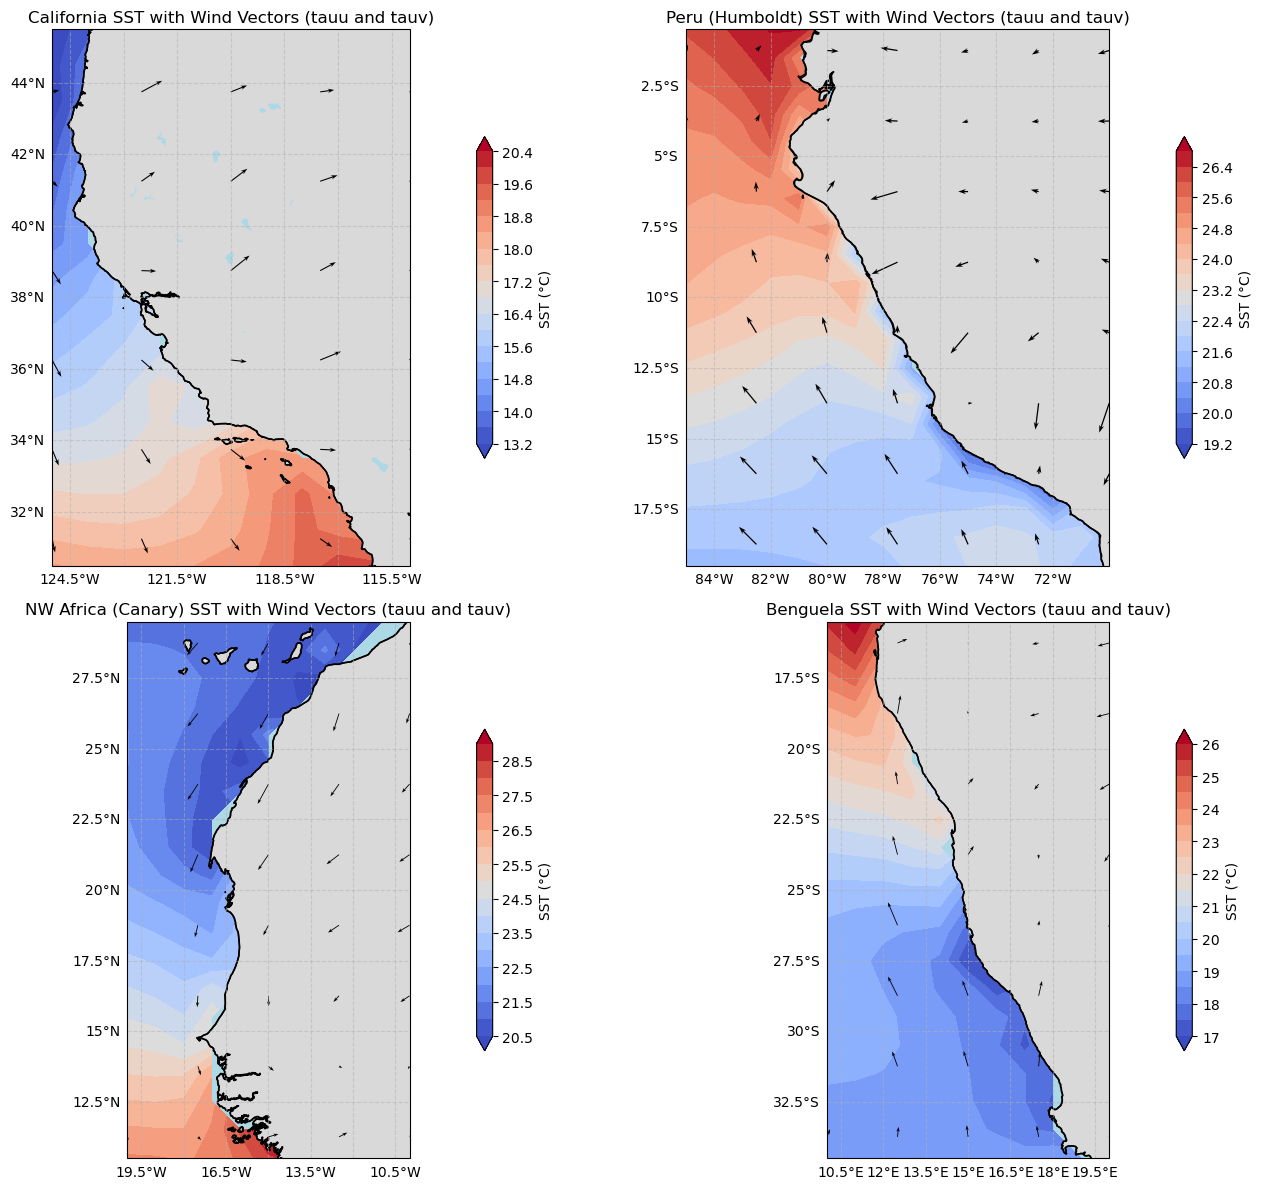

In [40]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# File paths for SST and wind stress components (tauu, tauv) for each EBUS region
regions = {
    
}

# Set up the figure and axes for the 4 regions
fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw={'projection': ccrs.PlateCarree()})

# Loop over the regions and plot each one
for ax, (region, paths) in zip(axes.flatten(), regions.items()):
    # Load the datasets for SST, tauu, and tauv for each region
    sst_ds = xr.open_dataset(paths['sst'])
    tauu_ds = xr.open_dataset(paths['tauu'])
    tauv_ds = xr.open_dataset(paths['tauv'])

    # Define the time range for the last 30 years (1985-2014)
    start_year = 1985
    end_year = 2014

    # Select the time period of interest
    sst_ds = sst_ds.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
    tauu_ds = tauu_ds.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
    tauv_ds = tauv_ds.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))

    # Average over time to get the mean SST, tauu, and tauv
    sst_data = sst_ds['tos_historical'].mean(dim='time')
    tauu_data = tauu_ds['tauu_historical'].mean(dim='time')
    tauv_data = tauv_ds['tauv_historical'].mean(dim='time')

    # Create the SST contour plot
    c = ax.contourf(sst_data['lon'], sst_data['lat'], sst_data, levels=20, cmap='coolwarm', extend='both', transform=ccrs.PlateCarree())

    # Add color bar
    cbar = fig.colorbar(c, ax=ax, orientation='vertical', shrink=0.6, pad=0.1)
    cbar.set_label('SST (°C)')

    # **Fix land-sea gap issue**
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)  # Fills ocean to prevent gaps
    ax.add_feature(cfeature.LAND, facecolor='#d9d9d9', edgecolor='black', zorder=1)  # Smooth land appearance
    ax.add_feature(cfeature.LAKES, facecolor='lightblue', zorder=2)  # Fills lakes to avoid gaps
    ax.coastlines(resolution='10m', linewidth=1.2, color='black')  # High-res coastline

    # Overlay wind vectors (tauu, tauv) on SST map
    scale = 2  # Adjust for visibility
    ax.quiver(tauv_data['lon'], tauv_data['lat'], tauu_data, tauv_data, scale=1.5, color='black', width=0.003, headwidth=4, headlength=6)

    # **Add Latitude & Longitude Gridlines**
    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
    gl.right_labels = False  # Remove longitude labels on the right
    gl.top_labels = False  # Remove latitude labels at the top

    # Set plot extent and labels
    ax.set_extent([sst_data['lon'].min(), sst_data['lon'].max(), sst_data['lat'].min(), sst_data['lat'].max()])
    ax.set_title(f"{region} SST with Wind Vectors (tauu and tauv)", fontsize=12)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    # Close datasets
    sst_ds.close()
    tauu_ds.close()
    tauv_ds.close()

# Adjust layout for subplots
plt.tight_layout()
# Save with a high DPI to reduce pixelation
plt.savefig('SST with Wind Vectors (tauu and tauv).png', dpi=600)  # Save with higher DPI
plt.show()


In [ ]:
### OBSERVATION DATA

In [ ]:
# ERSST

In [ ]:
# SUBSETTING ERSST

In [ ]:
import os
import xarray as xr

# Define the file paths for the ERSST data (all the netCDF files in the folder)
ersst_folder = "D:\\THESIS_DATA\\ERSST_DATA"
output_dir = "D:\\THESIS_DATA\\Extracted_ERSST_Outputs"

# Define the latitude and longitude bounds for each EBUS region
ebus_regions = {
    "California Current System": {"lon_min": -125, "lon_max": -115, "lat_min": 30, "lat_max": 46},
    "Peru (Humboldt) Current System": {"lon_min": -85, "lon_max": -70, "lat_min": -20, "lat_max": 0},
    "Benguela Current System": {"lon_min": 10, "lon_max": 20, "lat_min": -35, "lat_max": -15},
    "NW Africa (Canary) Current System": {"lon_min": -20, "lon_max": -10, "lat_min": 10, "lat_max": 30},
}

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Function to subset data for a given region
def subset_ebus_region(dataset, region_name, bounds):
    # Handle longitude bounds (considering 0 to 360 convention)
    if dataset.lon.max() > 180:
        lon_min = (bounds["lon_min"] + 360) if bounds["lon_min"] < 0 else bounds["lon_min"]
        lon_max = (bounds["lon_max"] + 360) if bounds["lon_max"] < 0 else bounds["lon_max"]
    else:
        lon_min = bounds["lon_min"]
        lon_max = bounds["lon_max"]
    
    return dataset.sel(
        lat=slice(bounds["lat_min"], bounds["lat_max"]),
        lon=slice(lon_min, lon_max)
    )

# Loop through each file in the ERSST folder
for file_name in os.listdir(ersst_folder):
    file_path = os.path.join(ersst_folder, file_name)
    
    # Check if it's a .nc file
    if file_path.endswith(".nc"):
        try:
            # Open the dataset
            ds = xr.open_dataset(file_path)
        except Exception as e:
            print(f"Error opening file {file_path}: {e}")
            continue

        # Loop through each region and subset the data
        for region_name, bounds in ebus_regions.items():
            subset = subset_ebus_region(ds, region_name, bounds)
            output_path = os.path.join(output_dir, f"{os.path.basename(file_path).replace('.nc', '')}_{region_name}_subset.nc")
            
            # Save the subsetted data
            subset.to_netcdf(output_path)
            #print(f"Saved {region_name} subset for {file_name} to {output_path}")

        # Close the dataset after processing the file
        ds.close()

print("Extraction completed!")


In [ ]:
# MERGING SUBSETTED ERSST BY REGIONS

import os
import xarray as xr

# Define the path where the SST files are stored
path_sst_files = r"D:\THESIS_DATA\Extracted_ERSST_Outputs"

# List all the files in the directory
files = os.listdir(path_sst_files)

# Initialize an empty dictionary to hold data for each region
region_data = {
    'Benguela': [],
    'California': [],
    'NW Africa (Canary)': [],
    'Peru (Humboldt)': []
}

# Loop through the files and assign data to the appropriate region
for file in files:
    # Only consider .nc files
    if file.endswith(".nc"):
        # Construct the file path
        file_path = os.path.join(path_sst_files, file)
        
        # Open the dataset
        ds = xr.open_dataset(file_path)
        
        # Extract the region from the filename
        if 'Benguela' in file:
            region = 'Benguela'
        elif 'California' in file:
            region = 'California'
        elif 'Canary' in file:
            region = 'NW Africa (Canary)'
        elif 'Humboldt' in file:
            region = 'Peru (Humboldt)'
        else:
            continue  # Skip files that do not match any known region
        
        # Extract the SST data (from the 'sst' variable)
        sst_data = ds['sst']  # 'sst' variable contains the sea surface temperature data
        
        # If the data contains multiple levels, we need to focus on the surface level (lev=0)
        sst_surface = sst_data.sel(lev=0, drop=True)  # Select the surface level (lev=0)
        
        # Append the SST data for the surface level to the respective region's list
        region_data[region].append(sst_surface)

# Now, let's merge the SST data for each region
merged_region_data = {}

for region, sst_list in region_data.items():
    if sst_list:  # Only merge if there is data for the region
        # Merge the list of data arrays into one dataset along the time dimension
        merged_data = xr.concat(sst_list, dim='time')
        
        # Store the merged data in the dictionary
        merged_region_data[region] = merged_data

# Check the merged data for each region
for region, merged_data in merged_region_data.items():
    print(f"Merged SST data for {region}:")
    print(merged_data)

# Optionally: Save the merged data to new NetCDF files for each region
for region, merged_data in merged_region_data.items():
    merged_data.to_netcdf(f"D:/THESIS_DATA/Merged_SST_{region}.nc")

    


In [ ]:
# TIME SERIES PLOTTING OF REGIONALLY MERGED DATA

In [ ]:
# ERSST TIME SERIES FOR THE LAST 30 YEARS FOR EBUS

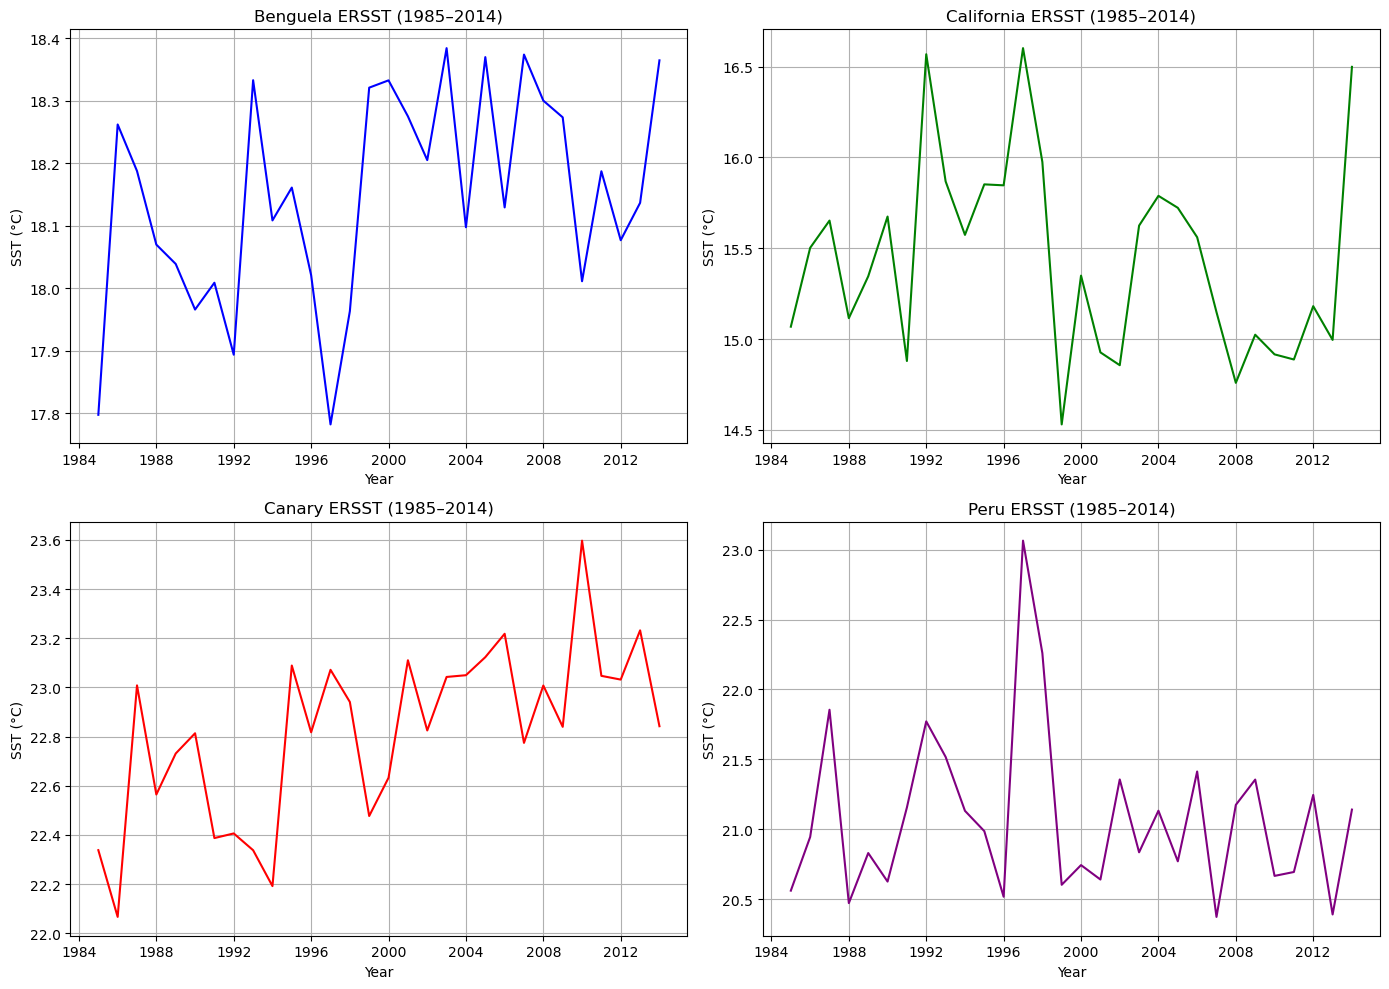

In [14]:
import xarray as xr
import matplotlib.pyplot as plt

# File paths
file_paths = {
    'Benguela': "D:\\THESIS_DATA\\ERSST_REGIONALLY\\Merged_SST_Benguela.nc",
    'California': "D:\\THESIS_DATA\\ERSST_REGIONALLY\\Merged_SST_California.nc",
    'Canary': "D:\\THESIS_DATA\\ERSST_REGIONALLY\\Merged_SST_NW Africa (Canary).nc",
    'Peru': "D:\\THESIS_DATA\\ERSST_REGIONALLY\\Merged_SST_Peru (Humboldt).nc"
}

# Variable of interest
variable = 'sst'

# Time range for the last 30 years
start_year = 1985
end_year = 2014

# Create a figure for subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # Flatten for easy iteration

# Colors for each region
region_colors = {
    'Benguela': 'blue',
    'California': 'green',
    'Canary': 'red',
    'Peru': 'purple'
}

# Loop through each region, load data, and plot
for i, (region, file_path) in enumerate(file_paths.items()):
    # Open dataset
    ds = xr.open_dataset(file_path)
    
    # Ensure time dimension is sorted
    ds = ds.sortby('time')
    
    # Select the time period of interest
    ds = ds.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
    
    # Compute the yearly mean, averaging over lat/lon
    yearly_mean = ds[variable].resample(time='YS').mean().mean(dim=['lat', 'lon'])
    
    # Plot on the corresponding subplot
    axes[i].plot(yearly_mean.time, yearly_mean, label=region, color=region_colors[region])
    
    # Customize subplot
    axes[i].set_title(f"{region} ERSST (1985–2014)", fontsize=12)
    axes[i].set_xlabel("Year", fontsize=10)
    axes[i].set_ylabel("SST (°C)", fontsize=10)
    axes[i].grid(True)
    #axes[i].legend()

    # Close dataset after processing
    ds.close()

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
# COBE_SST

In [ ]:
# SUBSETTING COBE_SST FOR EBUS


In [16]:
# SUBSETTING COBE_SST FOR EBUS
import xarray as xr
import os

# Define the file path for the COBE-SST dataset
file_paths = [
    "D:\\THESIS_DATA\\COBE_SST_DATA\\sst.mon.mean.nc"
]

# Define the latitude and longitude bounds for each EBUS region
ebus_regions = {
    "California Current System": {"lon_min": -125, "lon_max": -115, "lat_min": 30, "lat_max": 46},
    "Peru (Humboldt) Current System": {"lon_min": -85, "lon_max": -70, "lat_min": -20, "lat_max": 0},
    "Benguela Current System": {"lon_min": 10, "lon_max": 20, "lat_min": -35, "lat_max": -15},
    "NW Africa (Canary) Current System": {"lon_min": -20, "lon_max": -10, "lat_min": 10, "lat_max": 30},
}

# Output directory for extracted subsets
output_dir = "D:\\THESIS_DATA\\COBE_SST_REGIONAL_Outputs"
os.makedirs(output_dir, exist_ok=True)

# Function to subset data for a given region
def subset_ebus_region(dataset, region_name, bounds):
    """Subset SST data for a given EBUS region and handle longitude convention issues."""
    
    # Check longitude format
    if dataset.lon.max() > 180:  # If dataset uses (0, 360) longitude format
        lon_min = bounds["lon_min"] + 360 if bounds["lon_min"] < 0 else bounds["lon_min"]
        lon_max = bounds["lon_max"] + 360 if bounds["lon_max"] < 0 else bounds["lon_max"]
    else:
        lon_min = bounds["lon_min"]
        lon_max = bounds["lon_max"]

    # Latitude slicing - Ensure order is correct based on dataset
    if dataset.lat[0] > dataset.lat[-1]:  # If latitudes are decreasing
        lat_slice = slice(bounds["lat_max"], bounds["lat_min"])
    else:
        lat_slice = slice(bounds["lat_min"], bounds["lat_max"])

    # Longitude handling: Use `.where()` for cases crossing the 180° meridian
    if lon_min > lon_max:
        subset = dataset.sel(lat=lat_slice).where(
            (dataset.lon >= lon_min) | (dataset.lon <= lon_max),
            drop=True
        )
    else:
        subset = dataset.sel(lat=lat_slice, lon=slice(lon_min, lon_max))

    return subset

# Loop through each file and extract data for each region
for file_path in file_paths:
    model_name = os.path.basename(file_path).replace(".nc", "")
    
    try:
        ds = xr.open_dataset(file_path)
    except Exception as e:
        print(f"Error opening file {file_path}: {e}")
        continue

    for region_name, bounds in ebus_regions.items():
        subset = subset_ebus_region(ds, region_name, bounds)
        output_path = os.path.join(output_dir, f"{model_name}_{region_name}_subset.nc")

        # Save subset to a NetCDF file
        subset.to_netcdf(output_path)
        print(f"✅ Saved {region_name} subset for {model_name} to {output_path}")

    # Close dataset after processing
    ds.close()

print("🚀 Extraction completed successfully!")


✅ Saved California Current System subset for sst.mon.mean to D:\THESIS_DATA\COBE_SST_REGIONAL_Outputs\sst.mon.mean_California Current System_subset.nc
✅ Saved Peru (Humboldt) Current System subset for sst.mon.mean to D:\THESIS_DATA\COBE_SST_REGIONAL_Outputs\sst.mon.mean_Peru (Humboldt) Current System_subset.nc
✅ Saved Benguela Current System subset for sst.mon.mean to D:\THESIS_DATA\COBE_SST_REGIONAL_Outputs\sst.mon.mean_Benguela Current System_subset.nc
✅ Saved NW Africa (Canary) Current System subset for sst.mon.mean to D:\THESIS_DATA\COBE_SST_REGIONAL_Outputs\sst.mon.mean_NW Africa (Canary) Current System_subset.nc
🚀 Extraction completed successfully!


In [ ]:
# COBE_SST TIME SERIES FOR THE LAST 30 YEARS FOR EBUS

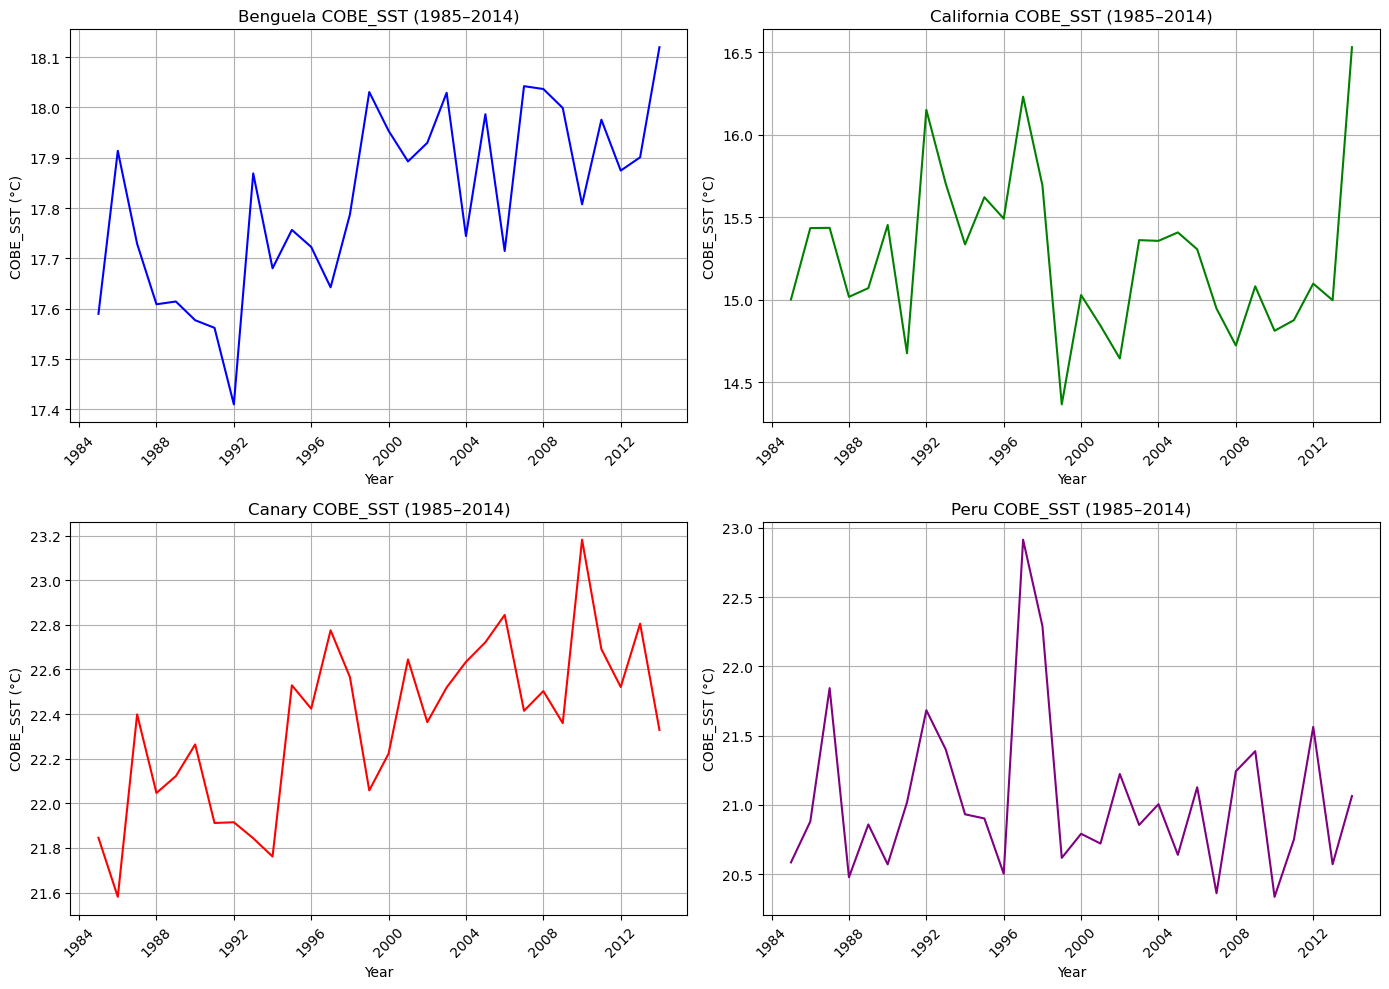

In [18]:
# COBE_SST TIME SERIES FOR THE LAST 30 YEARS FOR EBUS
import xarray as xr
import matplotlib.pyplot as plt

# File paths
file_paths = {
    'Benguela': "D:\\THESIS_DATA\\COBE_SST_REGIONAL_Outputs\\sst.mon.mean_Benguela Current System_subset.nc",
    'California': "D:\\THESIS_DATA\\COBE_SST_REGIONAL_Outputs\\sst.mon.mean_California Current System_subset.nc",
    'Canary': "D:\\THESIS_DATA\\COBE_SST_REGIONAL_Outputs\\sst.mon.mean_NW Africa (Canary) Current System_subset.nc",
    'Peru': "D:\\THESIS_DATA\\COBE_SST_REGIONAL_Outputs\\sst.mon.mean_Peru (Humboldt) Current System_subset.nc"
}

# Check if 'sst' is the correct variable name
variable = 'sst'

# Time range for the last 30 years
start_year = 1985
end_year = 2014

# Create a figure for subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # Flatten for easy iteration

# Colors for each region
region_colors = {
    'Benguela': 'blue',
    'California': 'green',
    'Canary': 'red',
    'Peru': 'purple'
}

# Loop through each region, load data, and plot
for i, (region, file_path) in enumerate(file_paths.items()):
    try:
        # Open dataset
        ds = xr.open_dataset(file_path)
        
        # Ensure time dimension is sorted
        ds = ds.sortby('time')
        
        # Select the time period of interest
        ds = ds.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
        
        # Drop missing values if any
        ds = ds.dropna(dim='time', how='all')
        
        # Compute the yearly mean, averaging over lat/lon
        yearly_mean = ds[variable].resample(time='YS').mean().mean(dim=['lat', 'lon'])
        
        # Plot on the corresponding subplot
        axes[i].plot(yearly_mean.time, yearly_mean, label=region, color=region_colors[region])
        
        # Customize subplot
        axes[i].set_title(f"{region} COBE_SST (1985–2014)", fontsize=12)
        axes[i].set_xlabel("Year", fontsize=10)
        axes[i].set_ylabel("COBE_SST (°C)", fontsize=10)
        axes[i].grid(True)
        
        # Rotate x-axis labels for better readability
        axes[i].tick_params(axis='x', rotation=45)

        # Close dataset after processing
        ds.close()
    
    except Exception as e:
        print(f"Error processing {region}: {e}")

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
# CHLOROPHYLL

In [ ]:
# SUBSETTING AND MERGING GLOBAL CHOROPHYLL OF SEAWIFS AND MODIS FOR THE EBUS

In [ ]:
import xarray as xr
import os
import glob

# -----------------------------
# Define EBUS regions (update as needed)
# -----------------------------
ebus_regions = {
    "California_Current_System": {
        "lon_min": -125, "lon_max": -115,
        "lat_min": 30, "lat_max": 46
    },
    "Peru_Humboldt_Current_System": {
        "lon_min": -85, "lon_max": -70,
        "lat_min": -20, "lat_max": 0
    },
    "Benguela_Current_System": {
        "lon_min": 10, "lon_max": 20,
        "lat_min": -35, "lat_max": -15
    },
    "NW_Africa_Canary_Current_System": {
        "lon_min": -20, "lon_max": -10,
        "lat_min": 10, "lat_max": 30
    },
}

# -----------------------------
# Define directories containing the global files
# -----------------------------
seawifs_dir = r"D:\THESIS_DATA\Chlorophyll\SEAWIF"  # SeaWiFS files (1998-2002)
modis_dir   = r"D:\THESIS_DATA\Chlorophyll\MODIS"    # MODIS files (2003-2014)

# Use glob to list all .nc files in each folder
seawifs_files = sorted(glob.glob(os.path.join(seawifs_dir, "*.nc")))
modis_files   = sorted(glob.glob(os.path.join(modis_dir, "*.nc")))



In [ ]:
# -----------------------------
# Function to subset dataset to a region based on bounds
# -----------------------------
def subset_region(ds, bounds):
    """
    Subset the dataset ds to the region defined in bounds.
    bounds is a dict with keys: lon_min, lon_max, lat_min, lat_max.
    It handles latitude ordering automatically.
    """
    # Determine the proper slice for latitude:
    if ds.lat[0] > ds.lat[-1]:
        # If latitude is in descending order, reverse the slice:
        lat_slice = slice(bounds["lat_max"], bounds["lat_min"])
    else:
        lat_slice = slice(bounds["lat_min"], bounds["lat_max"])
        
    # For longitude we assume the dataset uses -180 to 180
    ds_subset = ds.sel(lat=lat_slice, lon=slice(bounds["lon_min"], bounds["lon_max"]))
    return ds_subset



In [ ]:
# -----------------------------
# Directory to save merged outputs (create if needed)
# -----------------------------
output_dir = r"D:\THESIS_DATA\Chlorophyll\Merged"
os.makedirs(output_dir, exist_ok=True)

# -----------------------------
# Process each EBUS region
# -----------------------------
for region, bounds in ebus_regions.items():
    print(f"Processing region: {region}")
    
    # --- Process SeaWiFS files ---
    seawifs_subsets = []
    for f in seawifs_files:
        try:
            ds = xr.open_dataset(f)
            # If your chlorophyll variable is not named 'chlor_a', update accordingly.
            ds_subset = subset_region(ds, bounds)
            # Optionally, select only the variable of interest:
            ds_subset = ds_subset[['chlor_a']]
            seawifs_subsets.append(ds_subset)
            ds.close()
        except Exception as e:
            print(f"Error processing SeaWiFS file {f}: {e}")
    
    if seawifs_subsets:
        # Concatenate along the time dimension
        ds_seawifs_region = xr.concat(seawifs_subsets, dim="time")
    else:
        print(f"No SeaWiFS data for region {region}")
        continue  # Skip to the next region
    
    # --- Process MODIS files ---
    modis_subsets = []
    for f in modis_files:
        try:
            ds = xr.open_dataset(f)
            ds_subset = subset_region(ds, bounds)
            ds_subset = ds_subset[['chlor_a']]
            modis_subsets.append(ds_subset)
            ds.close()
        except Exception as e:
            print(f"Error processing MODIS file {f}: {e}")
    
    if modis_subsets:
        ds_modis_region = xr.concat(modis_subsets, dim="time")
    else:
        print(f"No MODIS data for region {region}")
        continue
    
    # --- Merge SeaWiFS and MODIS for the region ---
    # Concatenate along time dimension
    ds_merged = xr.concat([ds_seawifs_region, ds_modis_region], dim="time")
    # Optionally, sort by time if needed
    ds_merged = ds_merged.sortby("time")
    
    # Save the merged dataset to a NetCDF file
    out_path = os.path.join(output_dir, f"{region}_chlor_a_1998_2014.nc")
    ds_merged.to_netcdf(out_path)
    print(f"Saved merged dataset for {region} to {out_path}")

print("All regions processed and merged successfully!")


In [ ]:
# CHLOROPHYLL TIME SERIES FOR THE LAST 16 YEARS (TIME RANGE AVAILABLE FOR DOWNLOAD) FOR EBUS

In [ ]:
# CHLOROPHYLL TIME SERIES FOR EBUS REGIONS (COPERNICUS DATA)

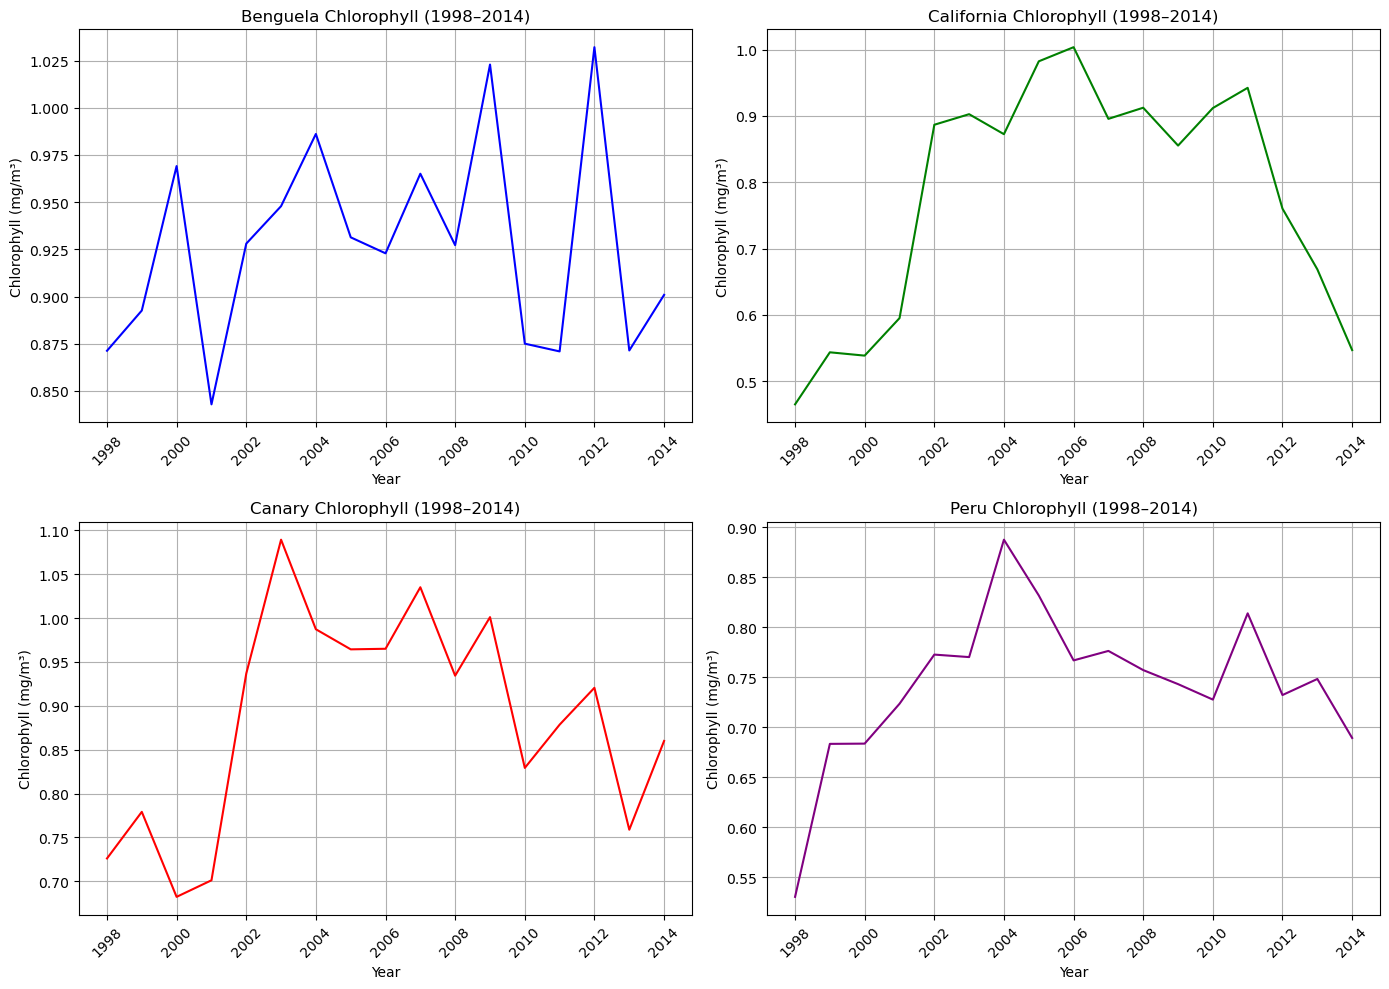

In [2]:
import xarray as xr
import matplotlib.pyplot as plt

# File paths for the regions
file_paths = {
    'Benguela': "D:\\THESIS_DATA\\Chlorophyll\\BENGUELA_c3s_obs-oc_glo_bgc-plankton_my_l4-multi-4km_P1M_1738499831910.nc",
    'California': "D:\\THESIS_DATA\\Chlorophyll\\CALIFORNIA_c3s_obs-oc_glo_bgc-plankton_my_l4-multi-4km_P1M_1738502620872.nc",
    'Canary': "D:\\THESIS_DATA\\Chlorophyll\\NW_AFRICA_c3s_obs-oc_glo_bgc-plankton_my_l4-multi-4km_P1M_1738508220661.nc",
    'Peru': "D:\\THESIS_DATA\\Chlorophyll\\PERU_c3s_obs-oc_glo_bgc-plankton_my_l4-multi-4km_P1M_1738503203344.nc"
}

# Variable name for chlorophyll (assuming it's 'CHL' based on your dataset)
variable = 'CHL'

# Time range for the last 30 years (adjust this as per your data)
start_year = 1998
end_year = 2014

# Create a figure for subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # Flatten for easy iteration

# Colors for each region
region_colors = {
    'Benguela': 'blue',
    'California': 'green',
    'Canary': 'red',
    'Peru': 'purple'
}

# Loop through each region, load data, and plot
for i, (region, file_path) in enumerate(file_paths.items()):
    try:
        # Open dataset
        ds = xr.open_dataset(file_path)
        
        # Ensure time dimension is sorted
        ds = ds.sortby('time')
        
        # Select the time period of interest
        ds = ds.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
        
        # Drop missing values if any
        ds = ds.dropna(dim='time', how='all')
        
        # Compute the yearly mean, averaging over lat/lon
        yearly_mean = ds[variable].resample(time='YS').mean().mean(dim=['latitude', 'longitude'])
        
        # Plot on the corresponding subplot
        axes[i].plot(yearly_mean.time, yearly_mean, label=region, color=region_colors[region])
        
        # Customize subplot
        axes[i].set_title(f"{region} Chlorophyll (1998–2014)", fontsize=12)
        axes[i].set_xlabel("Year", fontsize=10)
        axes[i].set_ylabel("Chlorophyll (mg/m³)", fontsize=10)
        axes[i].grid(True)
        
        # Rotate x-axis labels for better readability
        axes[i].tick_params(axis='x', rotation=45)

        # Close dataset after processing
        ds.close()
    
    except Exception as e:
        print(f"Error processing {region}: {e}")

# Adjust layout
plt.tight_layout()
plt.show()
